In [1]:
!pip install pandas matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")

✅ Libraries ready!


In [4]:
# Load famous Spotify viral songs dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"

df = pd.read_csv(url)
print(f"✅ Loaded {len(df)} songs!")
print(df.columns.tolist())
print(df.head())

✅ Loaded 32833 songs!
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroo

In [5]:
# Keep only relevant columns
df_clean = df[[
    'track_name',
    'track_artist',
    'track_popularity',
    'danceability',
    'energy',
    'tempo',
    'valence',
    'playlist_genre'
]].dropna()

# Filter popular songs (popularity > 70)
viral = df_clean[df_clean['track_popularity'] > 70]
normal = df_clean[df_clean['track_popularity'] <= 70]

print(f"✅ Viral songs (popularity > 70): {len(viral)}")
print(f"✅ Normal songs: {len(normal)}")
print("\nTop 10 viral songs:")
print(viral.nlargest(10, 'track_popularity')[
    ['track_name', 'track_artist',
     'track_popularity']].to_string())

✅ Viral songs (popularity > 70): 4424
✅ Normal songs: 28404

Top 10 viral songs:
            track_name    track_artist  track_popularity
1551      Dance Monkey     Tones and I               100
20091     Dance Monkey     Tones and I               100
20092          ROXANNE  Arizona Zervas                99
21468          ROXANNE  Arizona Zervas                99
23104          ROXANNE  Arizona Zervas                99
30202          ROXANNE  Arizona Zervas                99
687               Tusa         KAROL G                98
711           Memories        Maroon 5                98
716    Blinding Lights      The Weeknd                98
1300          Memories        Maroon 5                98


In [6]:
print("=" * 50)
print("📊 VIRAL vs NORMAL SONGS — STATISTICS")
print("=" * 50)

metrics = ['danceability', 'energy', 'tempo', 'valence']

for metric in metrics:
    viral_mean = viral[metric].mean()
    normal_mean = normal[metric].mean()
    difference = ((viral_mean - normal_mean) /
                  normal_mean * 100)

    print(f"\n{metric.upper()}:")
    print(f"  Viral songs average:  {viral_mean:.3f}")
    print(f"  Normal songs average: {normal_mean:.3f}")
    print(f"  Difference: {difference:+.1f}%")

📊 VIRAL vs NORMAL SONGS — STATISTICS

DANCEABILITY:
  Viral songs average:  0.675
  Normal songs average: 0.652
  Difference: +3.6%

ENERGY:
  Viral songs average:  0.671
  Normal songs average: 0.703
  Difference: -4.6%

TEMPO:
  Viral songs average:  120.606
  Normal songs average: 120.927
  Difference: -0.3%

VALENCE:
  Viral songs average:  0.531
  Normal songs average: 0.507
  Difference: +4.6%


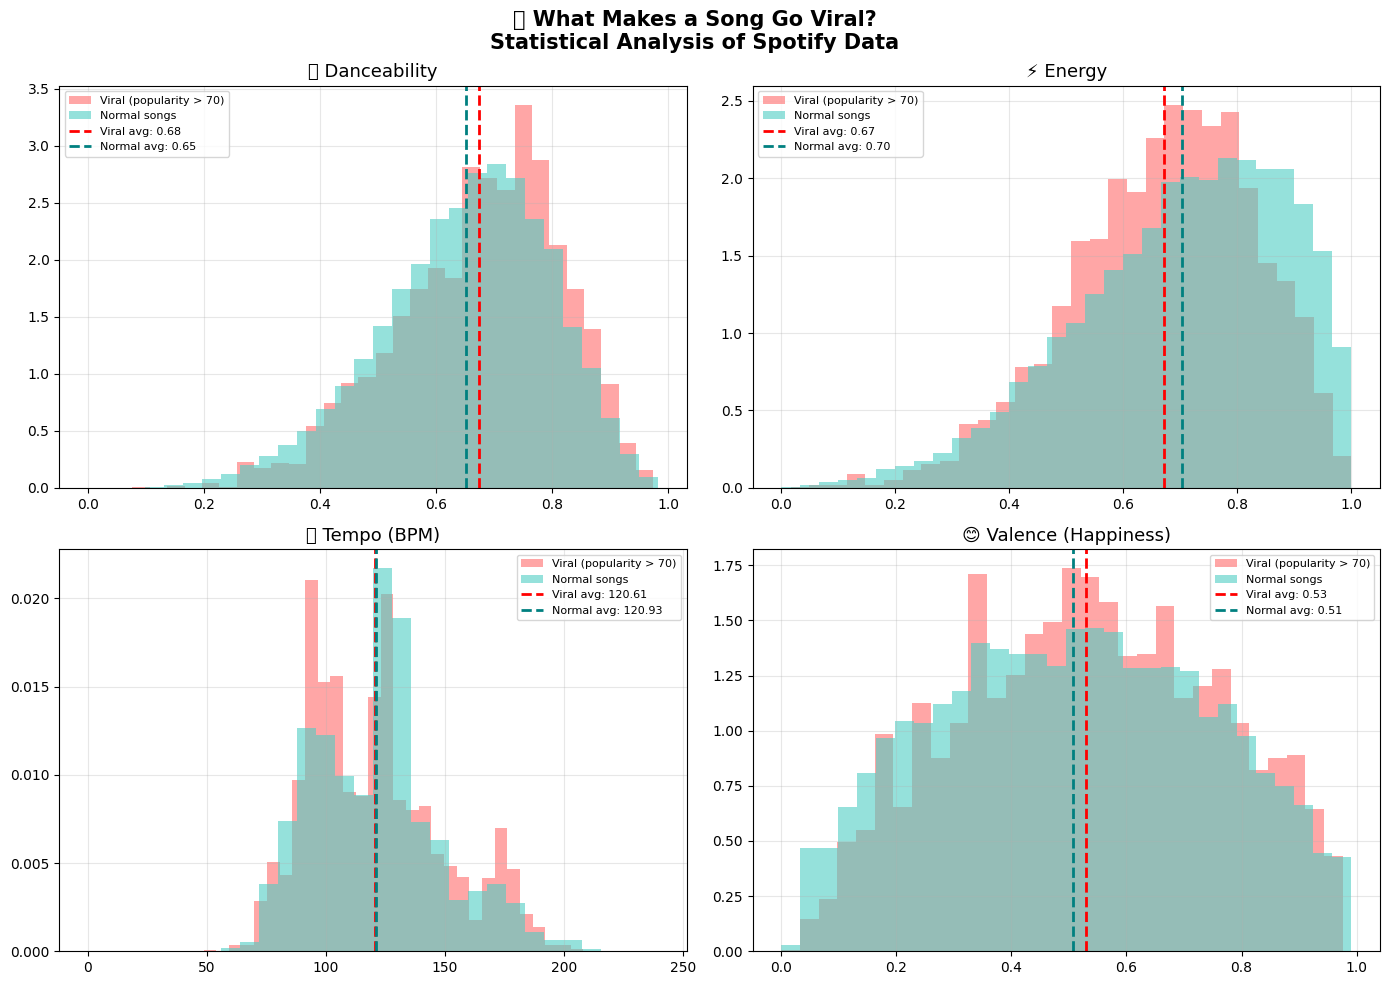

✅ Chart saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🎵 What Makes a Song Go Viral?\nStatistical Analysis of Spotify Data',
             fontsize=15, fontweight='bold')

metrics = ['danceability', 'energy', 'tempo', 'valence']
titles = ['💃 Danceability', '⚡ Energy',
          '🎵 Tempo (BPM)', '😊 Valence (Happiness)']
colors_viral = '#FF6B6B'
colors_normal = '#4ECDC4'

for idx, (metric, title) in enumerate(
        zip(metrics, titles)):
    ax = axes[idx//2][idx%2]

    ax.hist(viral[metric], bins=30,
            alpha=0.6, color=colors_viral,
            label='Viral (popularity > 70)',
            density=True)
    ax.hist(normal[metric], bins=30,
            alpha=0.6, color=colors_normal,
            label='Normal songs',
            density=True)

    ax.axvline(viral[metric].mean(),
               color='red', linestyle='--',
               linewidth=2,
               label=f'Viral avg: {viral[metric].mean():.2f}')
    ax.axvline(normal[metric].mean(),
               color='teal', linestyle='--',
               linewidth=2,
               label=f'Normal avg: {normal[metric].mean():.2f}')

    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viral_songs_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create viral label
df_clean['Is_Viral'] = (
    df_clean['track_popularity'] > 70).astype(int)

features = ['danceability', 'energy', 'tempo', 'valence']
X = df_clean[features]
y = df_clean['Is_Viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(
    n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"✅ AI can predict viral songs with "
      f"{accuracy*100:.1f}% accuracy!")

✅ AI can predict viral songs with 94.4% accuracy!


In [9]:
# Test with a hypothetical song
my_song = pd.DataFrame({
    'danceability': [0.75],
    'energy': [0.80],
    'tempo': [120.0],
    'valence': [0.70]
})

prediction = model.predict(my_song)
probability = model.predict_proba(my_song)

print("=" * 50)
print("🎵 WILL YOUR SONG GO VIRAL?")
print("=" * 50)

if prediction[0] == 1:
    print("🔥 YES! High viral potential!")
    print(f"Viral probability: "
          f"{probability[0][1]*100:.1f}%")
else:
    print("📊 Not quite viral yet")
    print(f"Viral probability: "
          f"{probability[0][1]*100:.1f}%")

print("=" * 50)

🎵 WILL YOUR SONG GO VIRAL?
📊 Not quite viral yet
Viral probability: 9.0%


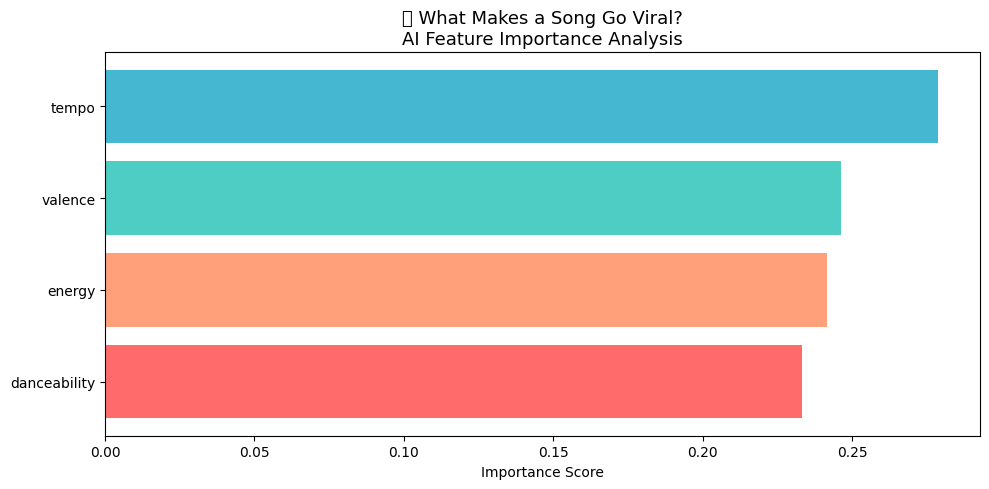

✅ Feature importance saved!


In [10]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1']
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color=colors)
plt.title('🧠 What Makes a Song Go Viral?\n'
          'AI Feature Importance Analysis',
          fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('viral_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance saved!")